<a href="https://colab.research.google.com/github/jerry124/Aprendizaje-Automatico/blob/main/Practica_Regresion_Logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica: Regresión Logística para Clasificación Binaria

**Alumno:** Gerardo Valdez Martínez  
**Tema:** Regresión logística aplicada a un problema de clasificación binaria  
**Objetivo general:** construir, evaluar e interpretar un modelo de regresión logística capaz de clasificar observaciones en dos clases: **0** y **1**.

---

## Explicación inicial

En esta práctica se trabaja con una base de datos de clasificación binaria. Esto significa que la variable objetivo solamente puede tomar dos valores posibles: **0** o **1**.

A diferencia de la regresión lineal, que se utiliza para predecir valores numéricos continuos, la **regresión logística** se utiliza para resolver problemas de clasificación. En este caso, el modelo no busca predecir una cantidad exacta, sino estimar la probabilidad de que una observación pertenezca a una clase.

Por ejemplo, el modelo puede responder algo como:

> "Esta observación tiene una probabilidad alta de pertenecer a la clase 1".

Este enfoque es muy útil cuando se tienen problemas de decisión, como clasificar si un correo es spam o no, si un paciente tiene una enfermedad o no, o si una observación pertenece a una clase determinada.

## 1. Importación de librerías

Primero se importan las librerías necesarias. Cada una cumple una función específica dentro del proyecto:

- **pandas:** permite cargar y manipular la base de datos.
- **numpy:** permite realizar operaciones numéricas.
- **matplotlib y seaborn:** sirven para crear gráficas.
- **scikit-learn:** contiene las herramientas para dividir datos, escalar variables, entrenar el modelo y evaluarlo.

In [25]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# División de datos y preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Configuración visual
plt.rcParams['figure.figsize'] = (8, 5)
sns.set_theme(style='whitegrid')

## 2. Carga de la base de datos

La base de datos contiene tres columnas:

- **x1:** primera variable de entrada.
- **x2:** segunda variable de entrada.
- **y:** variable objetivo o clase a predecir.

La variable **y** contiene dos clases:

- **0:** clase negativa.
- **1:** clase positiva.

Como el archivo no trae encabezados formales, se asignan nombres manualmente para que el análisis sea más claro.

In [26]:
# En Google Colab, primero sube el archivo CSV al panel de archivos.
# Después asegúrate de que el nombre sea exactamente: binary-classification-data (4).csv

ruta = 'binary-classification-data (4).csv'

try:
    df = pd.read_csv(ruta, header=None, names=['x1', 'x2', 'y'])
except FileNotFoundError:
    # Esta ruta funciona si el archivo se encuentra en /content/ dentro de Colab.
    ruta = '/content/binary-classification-data (4).csv'
    df = pd.read_csv(ruta, header=None, names=['x1', 'x2', 'y'])

# Mostramos las primeras filas para verificar que la carga fue correcta
df.head()

,x1,x2,y
0,0.051267,0.69956,1
1,-0.092742,0.68494,1
2,-0.213710,0.69225,1
3,-0.375000,0.50219,1
4,-0.513250,0.46564,1


## 3. Exploración inicial de los datos

Antes de entrenar cualquier modelo, es importante conocer la base de datos. En esta parte se revisan:

- cantidad de filas y columnas,
- nombres de las variables,
- tipos de datos,
- valores nulos,
- estadísticas generales.

Este paso es importante porque permite detectar errores o problemas antes de construir el modelo.

In [27]:
# Dimensiones del dataset
print('Filas y columnas:', df.shape)

# Información general
print('\nInformación del dataset:')
df.info()

Filas y columnas: (118, 3)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      118 non-null    float64
 1   x2      118 non-null    float64
 2   y       118 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.9 KB


In [28]:
# Revisión de valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
x1    0
x2    0
y     0
dtype: int64


In [29]:
# Estadísticas descriptivas
# Esto permite observar media, desviación estándar, valores mínimos y máximos.
df.describe()

,x1,x2,y
count,118.000000,118.000000,118.000000
mean,0.054779,0.183102,0.491525
std,0.496654,0.519743,0.502060
min,-0.830070,-0.769740,0.000000
25%,-0.372120,-0.254385,0.000000
50%,-0.006336,0.213455,0.000000
75%,0.478970,0.646563,1.000000
max,1.070900,1.108900,1.000000


## 4. Revisión del balance de clases

En clasificación es importante revisar si las clases están balanceadas. Si una clase tiene muchos más datos que la otra, el modelo podría aprender a favorecer la clase dominante.

Por eso se revisa cuántos ejemplos existen de la clase **0** y cuántos de la clase **1**.

y
0    60
1    58
Name: count, dtype: int64


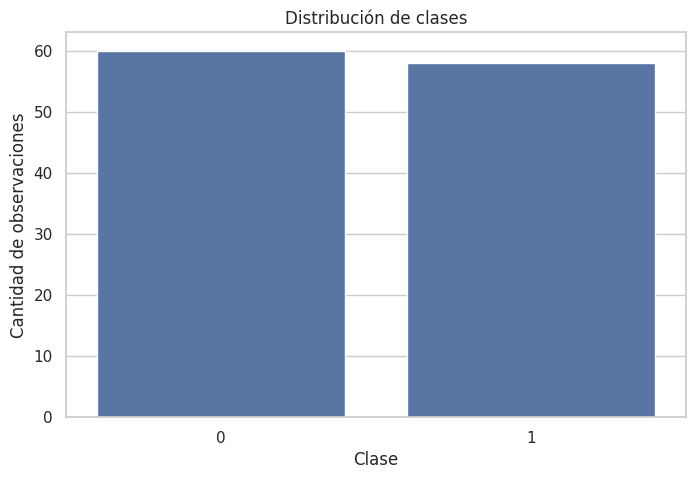

In [30]:
# Conteo de clases
conteo_clases = df['y'].value_counts().sort_index()
print(conteo_clases)

# Gráfica del balance de clases
sns.countplot(data=df, x='y')
plt.title('Distribución de clases')
plt.xlabel('Clase')
plt.ylabel('Cantidad de observaciones')
plt.show()

### Interpretación del balance de clases

Si las barras de la gráfica tienen alturas parecidas, significa que la base está relativamente balanceada. Esto es positivo porque el modelo tendrá ejemplos suficientes de ambas clases.

Si una barra fuera mucho más grande que la otra, se tendría que considerar alguna estrategia de balanceo. En esta práctica, primero se trabaja con los datos originales para entender el comportamiento natural del modelo.

## 5. Visualización de los datos

Como la base solamente tiene dos variables de entrada, se puede visualizar fácilmente en un plano. Esto es una gran ventaja porque permite observar si las clases se separan de manera lineal o si tienen una forma más compleja.

Cada punto representa una observación y el color indica la clase a la que pertenece.

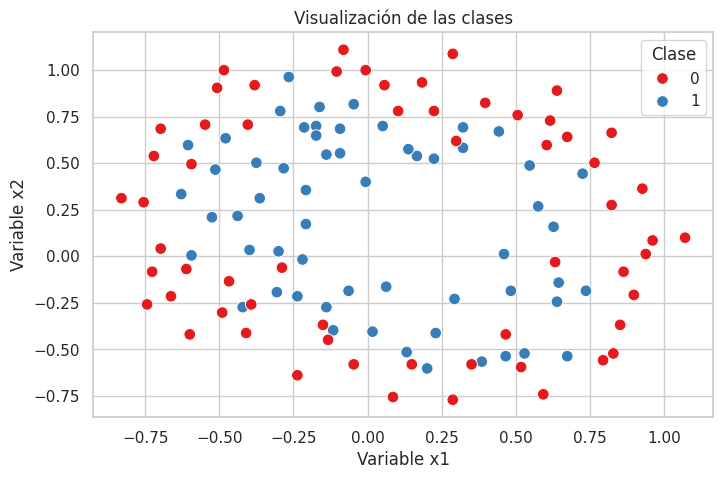

In [31]:
sns.scatterplot(data=df, x='x1', y='x2', hue='y', palette='Set1', s=70)
plt.title('Visualización de las clases')
plt.xlabel('Variable x1')
plt.ylabel('Variable x2')
plt.legend(title='Clase')
plt.show()

### Interpretación de la gráfica

En esta gráfica se puede observar cómo se distribuyen las clases. Si las clases pudieran separarse con una línea recta, la regresión logística simple tendría un desempeño muy alto.

Sin embargo, si las clases forman curvas, círculos o regiones no lineales, entonces una frontera recta puede quedarse corta. Esta observación es importante porque nos ayuda a entender las limitaciones del modelo.

## 6. Matriz de correlación

La matriz de correlación permite observar la relación lineal entre las variables. En este caso, ayuda a revisar qué tanto se relacionan **x1** y **x2** con la variable objetivo **y**.

Aunque la regresión logística no depende únicamente de la correlación, esta gráfica ayuda a tener una primera idea del comportamiento de los datos.

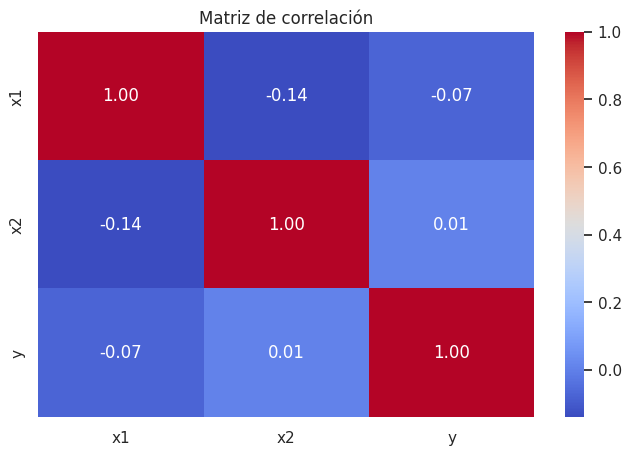

In [32]:
correlacion = df.corr()

sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

## 7. Separación de variables independientes y variable objetivo

En aprendizaje automático se acostumbra separar la información en:

- **X:** variables de entrada o características.
- **y:** variable objetivo que se desea predecir.

En este caso:

- **X = x1, x2**
- **y = clase 0 o clase 1**

In [33]:
# Variables independientes
X = df[['x1', 'x2']]

# Variable objetivo
y = df['y']

print('Tamaño de X:', X.shape)
print('Tamaño de y:', y.shape)

Tamaño de X: (118, 2)
Tamaño de y: (118,)


## 8. División en entrenamiento y prueba

Los datos se dividen en dos partes:

- **Entrenamiento:** se usa para que el modelo aprenda.
- **Prueba:** se usa para evaluar si el modelo aprendió correctamente.

Se utiliza una división de **80% entrenamiento** y **20% prueba**. Además, se usa `stratify=y` para mantener una proporción similar de clases en ambos conjuntos.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (94, 2)
X_test: (24, 2)
y_train: (94,)
y_test: (24,)


## 9. Modelo 1: Regresión logística simple

La regresión logística estima la probabilidad de que una observación pertenezca a la clase 1.

La idea general es:

\[
P(y=1)=\frac{1}{1+e^{-z}}
\]

Donde:

\[
z=b_0+b_1x_1+b_2x_2
\]

Si la probabilidad es mayor o igual a 0.5, el modelo clasifica como **1**. Si es menor a 0.5, clasifica como **0**.

En este primer modelo se usa una regresión logística simple con escalado de variables. El escalado ayuda a que las variables estén en una escala similar y el modelo pueda entrenarse de forma más estable.

In [35]:
# Pipeline: primero escala los datos y después entrena el modelo
modelo_logistico = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(random_state=42))
])

# Entrenamiento del modelo
modelo_logistico.fit(X_train, y_train)

print('Modelo entrenado correctamente.')

Modelo entrenado correctamente.


## 10. Predicciones del modelo simple

Después de entrenar el modelo, se realizan predicciones sobre el conjunto de prueba. Estas predicciones se comparan con los valores reales para evaluar qué tan bien funciona el modelo.

In [36]:
# Predicción de clases
y_pred = modelo_logistico.predict(X_test)

# Probabilidades de pertenecer a la clase 1
y_prob = modelo_logistico.predict_proba(X_test)[:, 1]

# Mostramos algunas predicciones
resultados = pd.DataFrame({
    'Real': y_test.values,
    'Predicción': y_pred,
    'Probabilidad clase 1': y_prob
})

resultados.head(10)

,Real,Predicción,Probabilidad clase 1
0,1,0,0.453263
1,0,1,0.519741
2,1,0,0.447243
3,0,0,0.488068
4,0,1,0.520869
5,1,0,0.471837
6,1,1,0.501397
7,1,1,0.512067
8,1,1,0.516048
9,1,0,0.492924


## 11. Evaluación del modelo simple

Para evaluar un modelo de clasificación no se usa R², porque R² pertenece a problemas de regresión. En clasificación se usan métricas como:

- **Accuracy:** porcentaje total de aciertos.
- **Precision:** de los casos que el modelo dijo que eran clase 1, cuántos realmente eran clase 1.
- **Recall:** de los casos que realmente eran clase 1, cuántos detectó correctamente el modelo.
- **F1-score:** promedio equilibrado entre precision y recall.

In [37]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

metricas_simple = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC'],
    'Valor': [accuracy, precision, recall, f1, auc]
})

metricas_simple

,Métrica,Valor
0,Accuracy,0.500000
1,Precision,0.500000
2,Recall,0.416667
3,F1-score,0.454545
4,AUC,0.479167


In [38]:
print('Reporte de clasificación:')
print(classification_report(y_test, y_pred))

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.50      0.58      0.54        12
           1       0.50      0.42      0.45        12

    accuracy                           0.50        24
   macro avg       0.50      0.50      0.50        24
weighted avg       0.50      0.50      0.50        24



## 12. Matriz de confusión

La matriz de confusión permite observar de forma más clara los aciertos y errores del modelo.

- **Verdaderos negativos:** clase 0 clasificada correctamente.
- **Verdaderos positivos:** clase 1 clasificada correctamente.
- **Falsos positivos:** el modelo predijo 1, pero era 0.
- **Falsos negativos:** el modelo predijo 0, pero era 1.

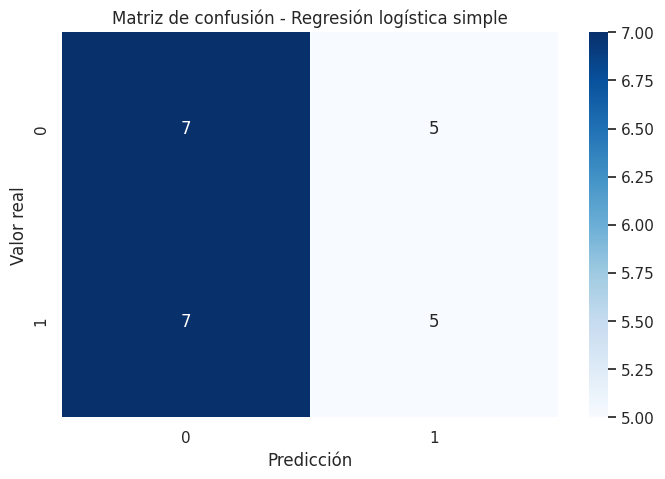

In [39]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión - Regresión logística simple')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

## 13. Curva ROC

La curva ROC permite evaluar el comportamiento del modelo considerando diferentes umbrales de clasificación. El valor AUC resume esta curva:

- Un AUC cercano a **1** indica un modelo con muy buena capacidad de clasificación.
- Un AUC cercano a **0.5** indica un modelo parecido a una decisión aleatoria.

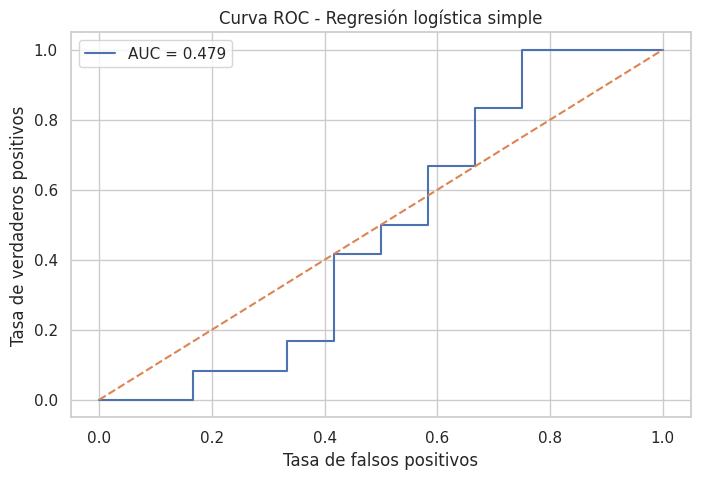

In [40]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Curva ROC - Regresión logística simple')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.legend()
plt.show()

## 14. Frontera de decisión del modelo simple

Una de las partes más importantes de esta práctica es visualizar la frontera de decisión. Esta frontera muestra cómo el modelo separa la clase 0 de la clase 1.

Como la regresión logística simple genera una frontera lineal, se espera observar una separación parecida a una línea recta.

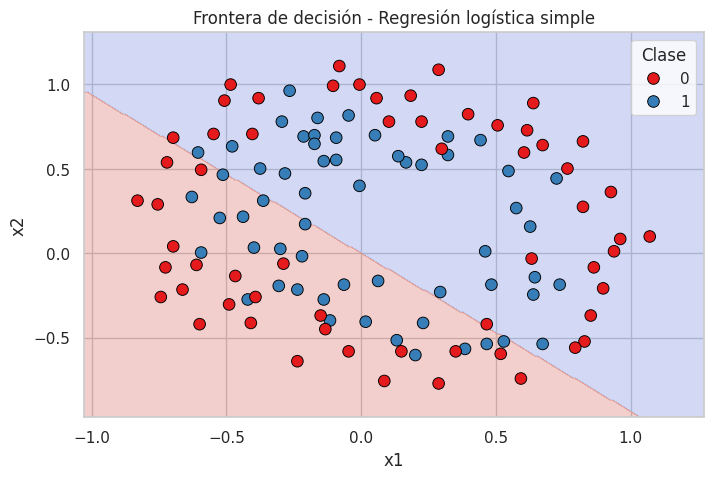

In [41]:
def graficar_frontera_decision(modelo, X, y, titulo):
    # Definimos los límites del plano
    x_min, x_max = X['x1'].min() - 0.2, X['x1'].max() + 0.2
    y_min, y_max = X['x2'].min() - 0.2, X['x2'].max() + 0.2

    # Creamos una malla de puntos para predecir la clase en todo el espacio
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    puntos = pd.DataFrame({
        'x1': xx.ravel(),
        'x2': yy.ravel()
    })

    Z = modelo.predict(puntos)
    Z = Z.reshape(xx.shape)

    # Graficamos las regiones de decisión
    plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    sns.scatterplot(x=X['x1'], y=X['x2'], hue=y, palette='Set1', s=70, edgecolor='black')
    plt.title(titulo)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend(title='Clase')
    plt.show()

# Frontera de decisión del modelo simple
graficar_frontera_decision(modelo_logistico, X, y, 'Frontera de decisión - Regresión logística simple')

### Interpretación de la frontera simple

La frontera de decisión muestra cómo el modelo separa las clases. Si los datos tienen una distribución no lineal, una línea recta puede no ser suficiente para separar correctamente todos los puntos.

Esto no significa que el modelo esté mal, sino que la relación entre las variables puede ser más compleja. Por eso, como mejora, se puede probar una versión con características polinomiales.

## 15. Modelo 2: Regresión logística con características polinomiales

En esta segunda parte se agrega una mejora al modelo. Se utilizan **características polinomiales**, lo que permite que la regresión logística genere una frontera de decisión curva.

Esto es útil cuando las clases no se separan bien con una línea recta.

La idea no es cambiar el modelo principal, sino transformar las variables de entrada para que el modelo pueda capturar relaciones más complejas.

In [42]:
modelo_polinomial = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(random_state=42, max_iter=1000))
])

modelo_polinomial.fit(X_train, y_train)

print('Modelo polinomial entrenado correctamente.')

Modelo polinomial entrenado correctamente.


## 16. Evaluación del modelo polinomial

Se evalúa el segundo modelo con las mismas métricas utilizadas anteriormente. Esto permite comparar de forma justa el desempeño de ambos modelos.

In [43]:
y_pred_poly = modelo_polinomial.predict(X_test)
y_prob_poly = modelo_polinomial.predict_proba(X_test)[:, 1]

accuracy_poly = accuracy_score(y_test, y_pred_poly)
precision_poly = precision_score(y_test, y_pred_poly)
recall_poly = recall_score(y_test, y_pred_poly)
f1_poly = f1_score(y_test, y_pred_poly)
auc_poly = roc_auc_score(y_test, y_prob_poly)

metricas_poly = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC'],
    'Valor': [accuracy_poly, precision_poly, recall_poly, f1_poly, auc_poly]
})

metricas_poly

,Métrica,Valor
0,Accuracy,0.791667
1,Precision,0.733333
2,Recall,0.916667
3,F1-score,0.814815
4,AUC,0.854167


In [44]:
print('Reporte de clasificación del modelo polinomial:')
print(classification_report(y_test, y_pred_poly))

Reporte de clasificación del modelo polinomial:
              precision    recall  f1-score   support

           0       0.89      0.67      0.76        12
           1       0.73      0.92      0.81        12

    accuracy                           0.79        24
   macro avg       0.81      0.79      0.79        24
weighted avg       0.81      0.79      0.79        24



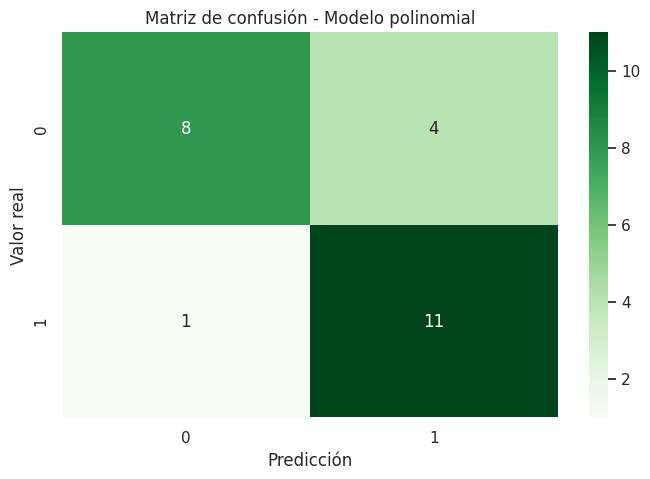

In [45]:
cm_poly = confusion_matrix(y_test, y_pred_poly)

sns.heatmap(cm_poly, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de confusión - Modelo polinomial')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

## 17. Frontera de decisión del modelo polinomial

Ahora se grafica la frontera de decisión del segundo modelo. En este caso, la frontera puede ser curva porque se agregaron características polinomiales.

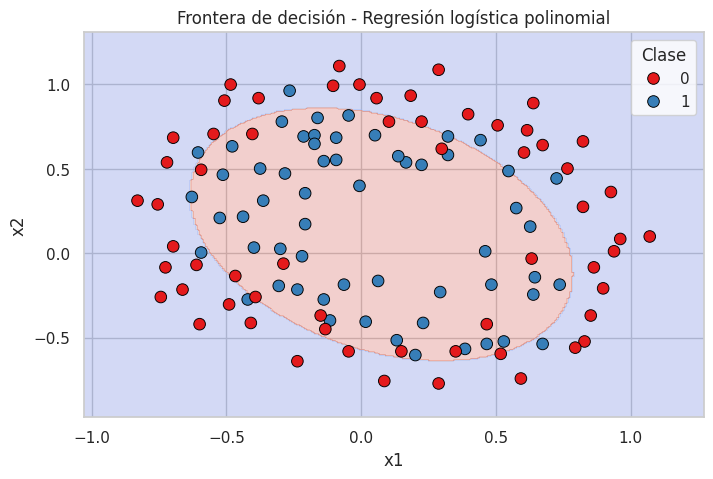

In [46]:
graficar_frontera_decision(modelo_polinomial, X, y, 'Frontera de decisión - Regresión logística polinomial')

## 18. Comparación de modelos

En esta tabla se comparan ambos modelos para decidir cuál tuvo mejor desempeño.

El primer modelo es más simple y fácil de interpretar, mientras que el segundo puede adaptarse mejor si los datos tienen una forma no lineal.

In [47]:
comparacion = pd.DataFrame({
    'Modelo': ['Regresión logística simple', 'Regresión logística polinomial'],
    'Accuracy': [accuracy, accuracy_poly],
    'Precision': [precision, precision_poly],
    'Recall': [recall, recall_poly],
    'F1-score': [f1, f1_poly],
    'AUC': [auc, auc_poly]
})

comparacion

,Modelo,Accuracy,Precision,Recall,F1-score,AUC
0,Regresión logística simple,0.500000,0.500000,0.416667,0.454545,0.479167
1,Regresión logística polinomial,0.791667,0.733333,0.916667,0.814815,0.854167


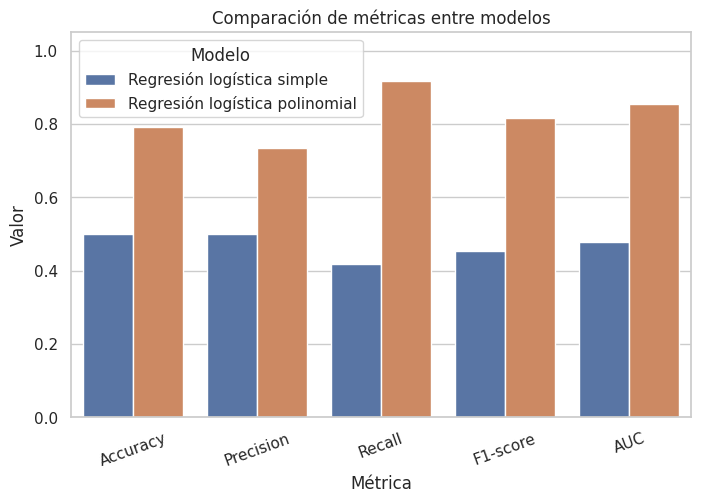

In [48]:
comparacion_melt = comparacion.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

sns.barplot(data=comparacion_melt, x='Métrica', y='Valor', hue='Modelo')
plt.title('Comparación de métricas entre modelos')
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.show()

## 19. Interpretación general de resultados

En esta práctica se observó que la regresión logística permite resolver un problema de clasificación binaria. El modelo simple construye una frontera de decisión lineal, lo cual es útil cuando las clases pueden separarse de forma aproximada mediante una línea recta.

Sin embargo, al visualizar los datos se puede notar que la distribución de las clases puede ser más compleja. Por esa razón se agregó un segundo modelo con características polinomiales, el cual permite generar una frontera de decisión curva.

La comparación de métricas permite identificar cuál modelo clasifica mejor las observaciones del conjunto de prueba. Si el modelo polinomial obtiene mejores resultados, esto indica que los datos tenían una relación no lineal y que una frontera recta no era suficiente.

Aun así, es importante mencionar que el modelo simple sigue siendo valioso porque permite comprender claramente la lógica de la regresión logística.

## 20. Conclusión

En conclusión, la regresión logística es un modelo adecuado para problemas de clasificación binaria, ya que permite estimar la probabilidad de pertenencia a una clase. En esta práctica se utilizó una base de datos con dos variables de entrada y una variable objetivo binaria.

El análisis exploratorio permitió conocer la estructura de los datos, revisar el balance de clases y visualizar la distribución de las observaciones. Posteriormente, se entrenó un modelo de regresión logística simple y se evaluó mediante métricas de clasificación como accuracy, precision, recall, F1-score y AUC.

Además, se agregó un segundo modelo con características polinomiales para analizar si una frontera de decisión curva podía mejorar la clasificación. Esta comparación fue importante porque permitió observar la diferencia entre un modelo lineal y una versión capaz de adaptarse a relaciones más complejas.

De manera general, esta práctica demuestra que no basta con entrenar un modelo, sino que también es necesario interpretar sus resultados, revisar sus errores y justificar las decisiones tomadas durante el proceso de análisis.



> En esta práctica trabajé con un problema de clasificación binaria. La variable objetivo solamente tiene dos posibles valores: 0 y 1. Por esa razón, el modelo adecuado no es una regresión lineal, sino una regresión logística.
>
> Primero realicé una exploración de los datos para conocer sus dimensiones, revisar valores nulos, analizar el balance de clases y visualizar la distribución de los puntos. Después separé las variables de entrada y la variable objetivo, dividí los datos en entrenamiento y prueba, y apliqué escalado para mejorar el entrenamiento del modelo.
>
> Posteriormente entrené una regresión logística simple y evalué su desempeño con métricas propias de clasificación, como accuracy, precision, recall, F1-score y matriz de confusión. También grafiqué la frontera de decisión para observar cómo el modelo separa las clases.
>
> Finalmente, como mejora, entrené un segundo modelo con características polinomiales. Esto permitió comparar una frontera lineal contra una frontera curva. Esta parte es importante porque muestra que, cuando los datos no se separan de forma lineal, una transformación polinomial puede ayudar a mejorar la clasificación.